1. S-a efectuat un studiu despre starea domeniului Data Science, iar datele colectate sunt salvate in fisierul "data/surveyDataScience.csv".



In [3]:
import numpy as np
import pandas as pd

# Obtinerea datelor din fisier

!wget -O surveyDataSience.csv https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/surveyDataSience.csv

data = pd.read_csv("surveyDataSience.csv")

data

--2026-03-07 10:10:20--  https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/surveyDataSience.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35220982 (34M) [text/plain]
Saving to: ‘surveyDataSience.csv’

surveyDataSience.cs 100%[===================>]  33.59M  --.-KB/s    in 0.08s   

2026-03-07 10:10:20 (424 MB/s) - ‘surveyDataSience.csv’ saved [35220982/35220982]



/tmp/ipykernel_639/4279154857.py:8: DtypeWarning: Columns (0,18,32,49,56,69,88,100,107,113,139,184,195,201,202,253,266,278,283,285,286,287,288,289,290,291,292,301,322,339,347,355,367) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("surveyDataSience.csv")


,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,NaN,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Python,NaN,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25969,1756,30-34,Man,Egypt,Bachelor’s degree,Data Analyst,1-3 years,Python,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25970,253,22-24,Man,China,Master’s degree,Student,1-3 years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25971,494,50-54,Man,Sweden,Doctoral degree,Research Scientist,I have never written code,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25972,277,45-49,Man,United States of America,Master’s degree,Data Scientist,5-10 years,Python,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Numarul de respondenti (de la care s-au colectat informatiile)
# data.shape() --> intoarce dimensiunea dataset-ului : (numar_randuri, numar_coloane)

num_respondents = data.shape[0] - 1
print(f"Numarul de respondenti: {num_respondents}")

Number of respondents: 25973


In [14]:
# Numar si tipul informatiilor (atributelor, proprietatilor) detinute pentru un respondent
num_columns = len(data.columns)
column_types = data.dtypes
print(f"Numarul de atribute: {num_columns}")
print(f"Tipul informatiilor: {column_types}")

Numarul de atribute: 369
Tipul informatiilor: Time from Start to Finish (seconds)    object
Q1                                     object
Q2                                     object
Q3                                     object
Q4                                     object
                                        ...  
Q38_B_Part_8                           object
Q38_B_Part_9                           object
Q38_B_Part_10                          object
Q38_B_Part_11                          object
Q38_B_OTHER                            object
Length: 369, dtype: object


In [19]:
# Numarul de respondenti pentru care se detin date complete
complete_data = data.dropna()
num_complete_respondents = len(complete_data)
print(f"Numarul de respondenti cu date complete: {num_complete_respondents}")

Numarul de respondenti cu date complete: 1


In [39]:
# Durata medie a anilor de studii superioare pentru acesti respondenti (cea efectiva sau cea estimata), durata medie a anilor de studii pentru respondentii din Romania si
# durata medie a anilor de studii pentru respondentii din Romania care sunt femei. Comparati rezultatele obtinute pentru cele trei grupuri de respondenti.
# Se presupune ca studiile de licenta dureaza 3 ani, cele de master 2 ani si cele de doctorat 3 ani.

average_years = 0
for index, row in data.iloc[1:].iterrows():
  sum = 0
  if row['Q4'] == "Bachelor's degree":
    sum += 3
  elif row['Q4'] == "Master's degree":
    sum += 5
  elif row['Q4'] == "Doctoral degree":
    sum += 8
  average_years += sum

average_years /= num_respondents
print(f"Durata medie a anilor de studii superioare pentru acesti respondenti: {average_years}")


mapping = {
    "Bacelor's degree": 3,
    "Master's degree": 5,
    "Doctoral degree": 8
}

romania_respondents = data[data['Q3'] == 'Romania']
average_years_romania = romania_respondents['Q4'].map(mapping).mean()

print(f"Durata medie a anilor de studii superioare pentru acesti respondenti din Romania: {average_years_romania}")

romania_female_respondents = romania_respondents[romania_respondents['Q2'] == 'Woman']
average_years_romania_female = romania_female_respondents['Q4'].map(mapping).mean()

print(f"Durata medie a anilor de studii superioare pentru acesti respondenti din Romania care sunt femei: {average_years_romania_female}")


Durata medie a anilor de studii superioare pentru acesti respondenti: 0.8608940053132099
Durata medie a anilor de studii superioare pentru acesti respondenti din Romania: 8.0
Durata medie a anilor de studii superioare pentru acesti respondenti din Romania care sunt femei: 8.0


In [42]:
# Numarul de respondenti femei din Romania pentru care se detin date complete
romania_respondens_complete = len(romania_female_respondents.dropna())
print(f"Numarul de respondenti femei din Romania pentru care se detin date complete: {romania_respondens_complete}")


Numarul de respondenti femei din Romania pentru care se detin date complete: 0


In [66]:
# Numarul de femei din Romania care programeaza in Python, precum si intervalul de varsta cu cele mai multe femei care programeaza in Python?
# Dar in C++? Comparati rezultatele obtinute pentru cele doua limbaje de programare.

num_of_woman_python = len(romania_female_respondents[romania_female_respondents['Q7_Part_1'] == "Python"])
print(f"Numarul de femei din Romania care programeaza in Python: {num_of_woman_python}")

woman_respondents = data[data['Q2'] == "Woman"]

woman_respondents_python = woman_respondents[woman_respondents['Q7_Part_1'] == "Python"]
woman_respondents_cpp = woman_respondents[woman_respondents['Q7_Part_5'] == "C++"]

age_python = woman_respondents_python['Q1'].value_counts()
age_python_max_interval = age_python.idxmax()

age_cpp = woman_respondents_cpp['Q1'].value_counts()
age_cpp_max_interval = age_cpp.idxmax()

print(f"Intervalul de varsta cu cele mai multe femei care programeaza in Python: {age_python_max_interval}")
print(f"Intervalul de varsta cu cele mai multe femei care programeaza in C++: {age_cpp_max_interval}")
print("Cele doua intervale de varsta sunt identice!")

Numarul de femei din Romania care programeaza in Python: 12
Intervalul de varsta cu cele mai multe femei care programeaza in Python: 18-21
Intervalul de varsta cu cele mai multe femei care programeaza in C++: 18-21
Cele doua intervale de varsta sunt identice!


In [67]:
# Domeniul de valori posibile si valorile extreme pentru fiecare atribut/proprietate (feature). In cazul proprietatilor nenumerice,
# cate valori posibile are fiecare astfel de proprietate

numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

print("Atributele numerice: ")
print()

if(numeric_columns.empty):
  print("Nu exista atribute numerice!")
  print()

for col in numeric_columns:
  print(col)
  print("Min: ", data[col].min())
  print("Max: ", data[col].max())
  print()

other_columns = data.select_dtypes(include=['object']).columns

print("Atributele nenumerice: ")
for col in other_columns:
  print(col)
  print("Numar valori posibile: ", data[col].nunique())
  print()

Atributele numerice: 

Nu exista atribute numerice!

Atributele nenumerice: 
Time from Start to Finish (seconds)
Numar valori posibile:  5410

Q1
Numar valori posibile:  12

Q2
Numar valori posibile:  6

Q3
Numar valori posibile:  67

Q4
Numar valori posibile:  8

Q5
Numar valori posibile:  16

Q6
Numar valori posibile:  8

Q7_Part_1
Numar valori posibile:  2

Q7_Part_2
Numar valori posibile:  2

Q7_Part_3
Numar valori posibile:  2

Q7_Part_4
Numar valori posibile:  2

Q7_Part_5
Numar valori posibile:  2

Q7_Part_6
Numar valori posibile:  2

Q7_Part_7
Numar valori posibile:  2

Q7_Part_8
Numar valori posibile:  2

Q7_Part_9
Numar valori posibile:  2

Q7_Part_10
Numar valori posibile:  2

Q7_Part_11
Numar valori posibile:  2

Q7_Part_12
Numar valori posibile:  1

Q7_OTHER
Numar valori posibile:  2

Q8
Numar valori posibile:  13

Q9_Part_1
Numar valori posibile:  2

Q9_Part_2
Numar valori posibile:  2

Q9_Part_3
Numar valori posibile:  2

Q9_Part_4
Numar valori posibile:  2

Q9_Part_5
Nu

In [70]:
# Transformati informatiile despre vechimea in programare in numar de ani (folositi in locul intervalului, mijlocul acestuia) si apoi calculati momentele de ordin 1 si 2
# pentru aceasta variabila (minim, maxim, media, deviatia standard, mediana). Ce se poate spune despre aceasta variabila?

experience_map = {
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25
}

data_copy = pd.read_csv("surveyDataSience.csv")

data_copy["Experience (Years)"] = data_copy['Q6'].map(experience_map).copy()

data_copy_clean = data_copy["Experience (Years)"].dropna()

print(f"Min: {data_copy_clean.min()}") #years in programming
print(f"Max: {data_copy_clean.max()}")
print(f"Mean: {data_copy_clean.mean()}")
print(f"Standard deviation: {data_copy_clean.std()}")
print(f"Median: {data_copy_clean.median()}")

Min: 0.5
Max: 25.0
Mean: 5.499579006455234
Standard deviation: 6.842720555613673
Median: 2.0


/tmp/ipykernel_639/911060623.py:13: DtypeWarning: Columns (0,18,32,49,56,69,88,100,107,113,139,184,195,201,202,253,266,278,283,285,286,287,288,289,290,291,292,301,322,339,347,355,367) have mixed types. Specify dtype option on import or set low_memory=False.
  data_copy = pd.read_csv("surveyDataSience.csv")


1. b Sa se vizualizeze

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_639/3659774874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="Blues_r")


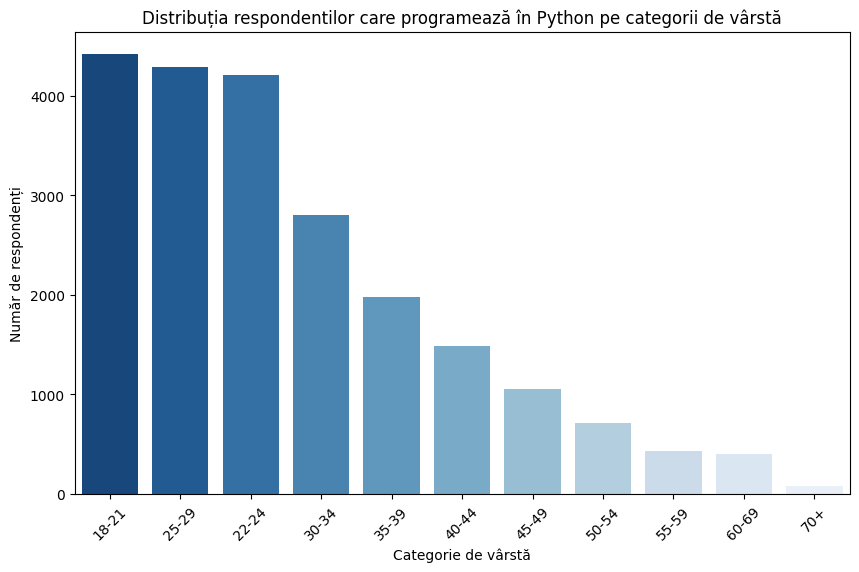

In [75]:
# Distributia respondentilor care programeaza in Python pe categorii de varsta

programmers_python = data[data['Q7_Part_1'] == "Python"].sort_index()
age_distribution = programmers_python['Q1'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="Blues_r")
plt.xlabel("Categorie de vârstă")
plt.ylabel("Număr de respondenți")
plt.title("Distribuția respondentilor care programează în Python pe categorii de vârstă")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_639/663958485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="rocket")


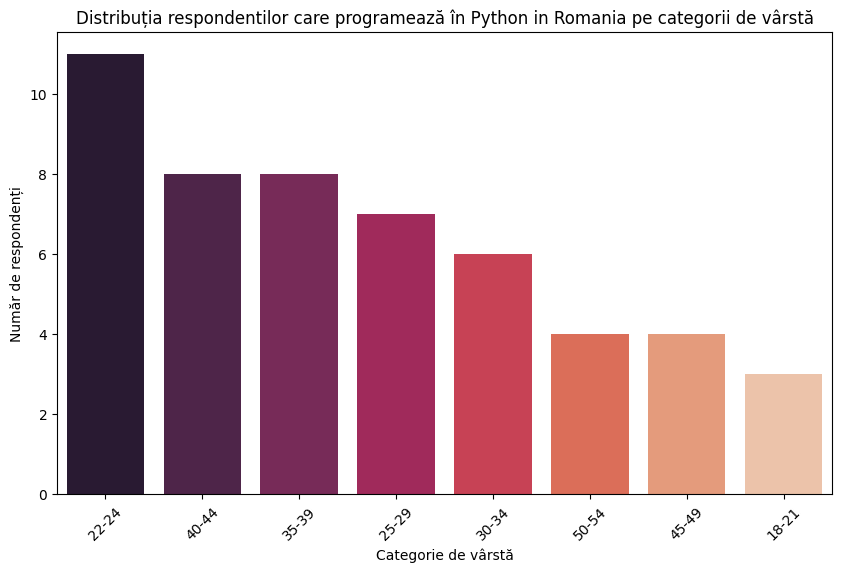

In [79]:
# Distributia respondentilor din Romania care programeaza in Python pe categorii de varsta
programmers_python_romania = programmers_python[programmers_python['Q3'] == "Romania"].sort_index()

age_distribution = programmers_python_romania['Q1'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="rocket")
plt.xlabel("Categorie de vârstă")
plt.ylabel("Număr de respondenți")
plt.title("Distribuția respondentilor care programează în Python in Romania pe categorii de vârstă")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_639/258957511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="rocket")


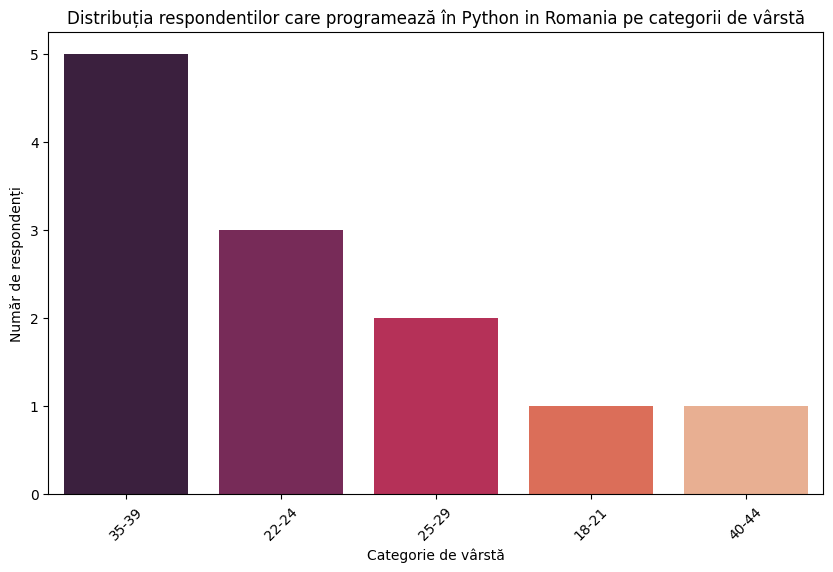

In [80]:
# Distributia respondentilor femei din Romania care programeaza in Python pe categorii de varsta

programmers_python_romania_women = programmers_python_romania[programmers_python_romania['Q2'] == "Woman"]

age_distribution = programmers_python_romania_women['Q1'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="rocket")
plt.xlabel("Categorie de vârstă")
plt.ylabel("Număr de respondenți")
plt.title("Distribuția respondentilor care programează în Python in Romania pe categorii de vârstă")
plt.xticks(rotation=45)
plt.show()

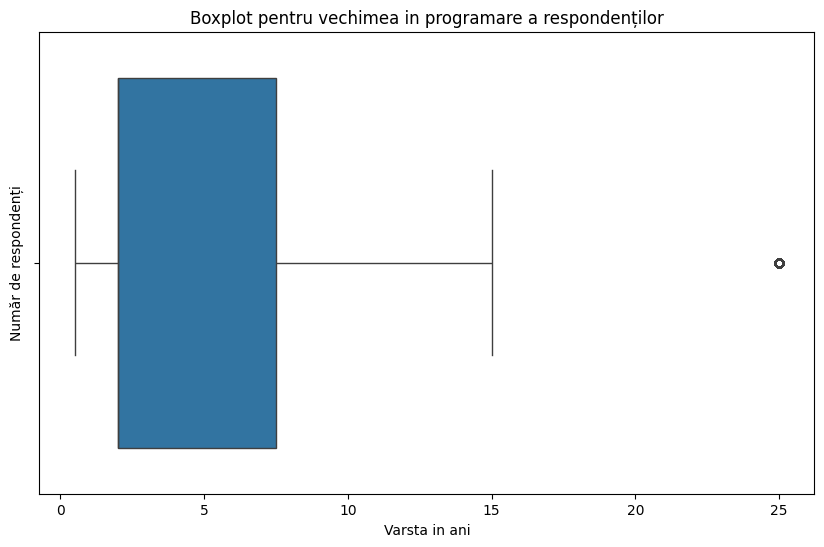

In [84]:
# Respondentii care pot fi considerati "outlieri" din punct de vedere al vechimii in programare (puteti folositi un boxplot pentru a identifica aceste valori)
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_copy['Experience (Years)'])
plt.xlabel("Varsta in ani")
plt.ylabel("Număr de respondenți")
plt.title("Boxplot pentru vechimea in programare a respondenților")
plt.show()

In [10]:
import requests
import random
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import math

In [11]:
api_url = "https://api.github.com/repos/lauradiosan/AI-UBB/contents/2025-2026/labs/lab02/data/images" # returneaza lista fisierelor din acel folder

response = requests.get(api_url) # cerere http catre github api, daca a fost cu succes se returneaza 200
if response.status_code == 200:
    files = response.json()

# Filtrăm doar imaginile (fișiere cu extensii .jpg, .png, .jpeg)
image_files = [file["name"] for file in files if file["name"].endswith((".jpg", ".png", ".jpeg"))]

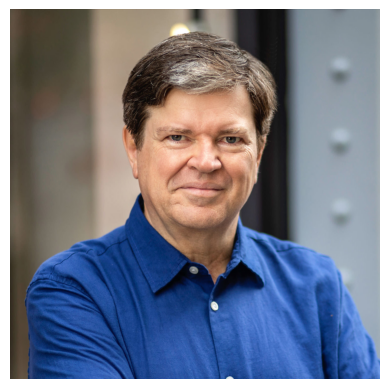

In [17]:
# Sa se vizualizeze una din imagini
if image_files:
  selected_image = random.choice(image_files)
  raw_url = f"https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2024-2025/labs/lab02/data/images/{selected_image}"

img_response = requests.get(raw_url)
if img_response.status_code == 200:
    image = Image.open(BytesIO(img_response.content))

plt.imshow(image)
plt.axis("off")
plt.show()

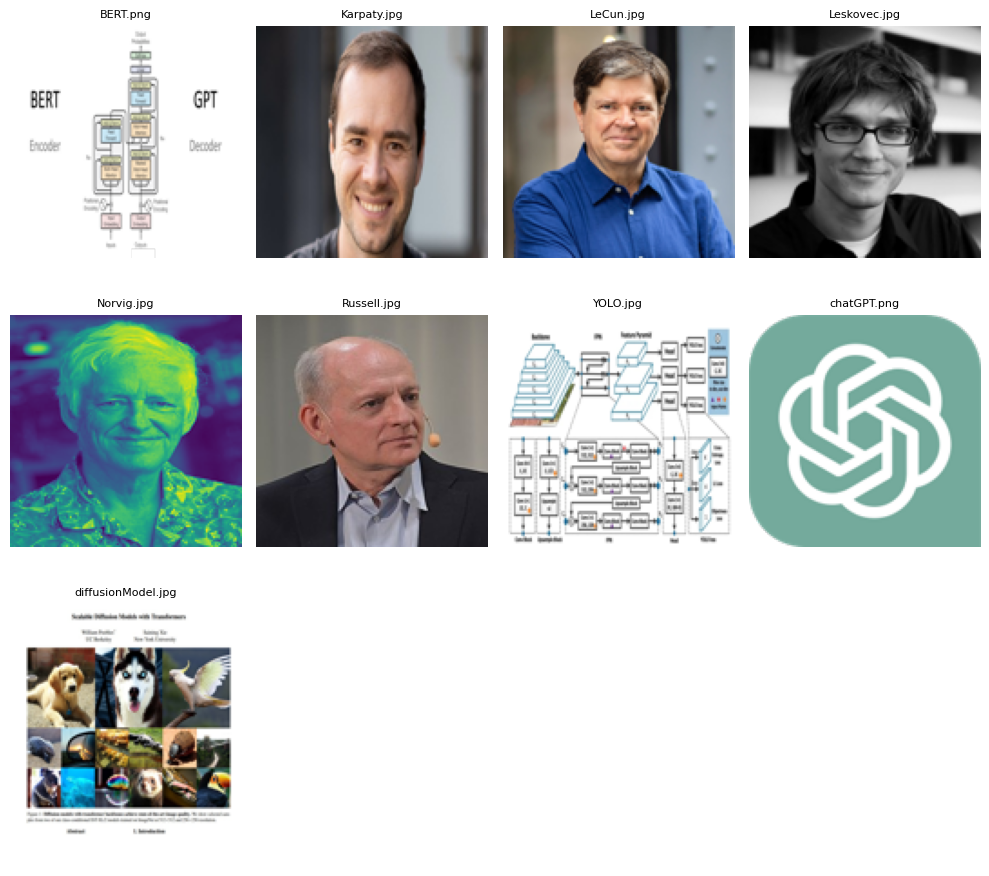

In [23]:
# Daca imaginile nu aceeasi dimensiune, sa se redimensioneze toate la 128 x 128 pixeli si sa se vizualizeze imaginile intr-un cadru tabelar.
if image_files:
  images = []
  for img in image_files:
      raw_url = f"https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2024-2025/labs/lab02/data/images/{img}"
      img_response = requests.get(raw_url)
      if img_response.status_code == 200:
          image = Image.open(BytesIO(img_response.content))
          image = image.resize((128, 128))
          images.append((img, image))

  num_images = len(images)
  num_cols = 4
  rows = math.ceil(num_images / num_cols)

  fig, axes = plt.subplots(rows, num_cols, figsize=(10, rows * 3))
  axes = axes.flatten()

  for ax, (name, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(name, fontsize=8)
    ax.axis("off")

  for ax in axes[num_images:]:
      ax.axis("off")

  plt.tight_layout()
  plt.show()
else:
  print("Nu s-au găsit imagini în acest folder.")

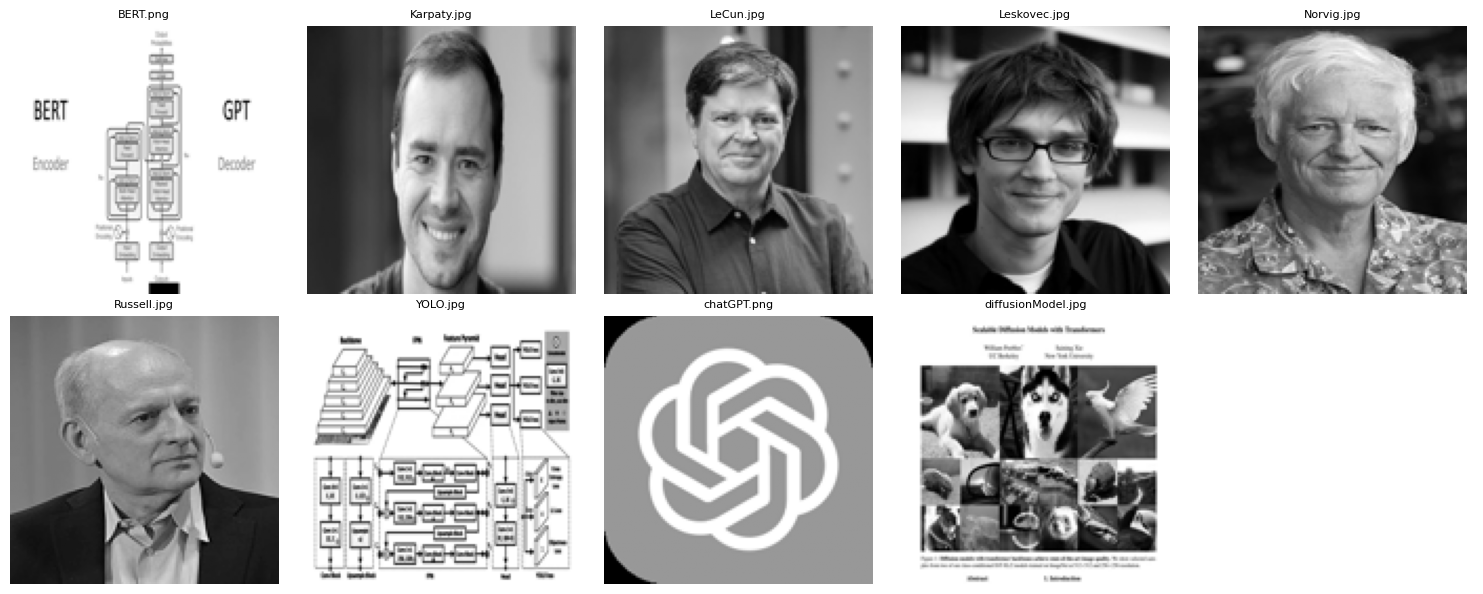

In [24]:
# Sa se transforme imaginile in format gray-levels si sa se vizualizeze
if image_files:
  images = []
  for img_name in image_files:
    raw_url = f"https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2024-2025/labs/lab02/data/images/{img_name}"
    img_response = requests.get(raw_url)
    if img_response.status_code == 200:
      image = Image.open(BytesIO(img_response.content))
      grayscale_image = image.convert("L")  # Convertim în gray-levels
      grayscale_image = grayscale_image.resize((128, 128))
      images.append((img_name, grayscale_image))

  num_images = len(images)
  cols = 5
  rows = math.ceil(num_images / cols)

  fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
  axes = axes.flatten()

  for ax, (name, img) in zip(axes, images):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")

  for ax in axes[num_images:]:
    ax.axis("off")

  plt.tight_layout()
  plt.show()

In [29]:
import requests
import random
from PIL import ImageFilter
from io import BytesIO
import matplotlib.pyplot as plt

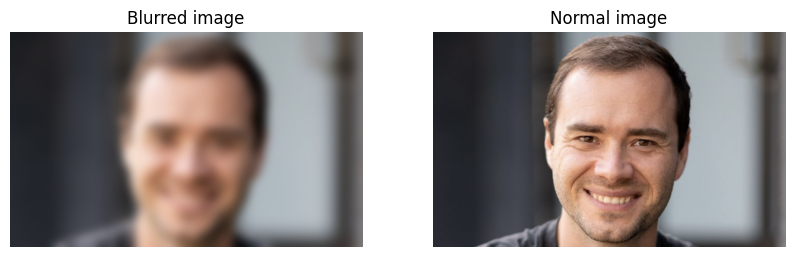

In [45]:
# Sa se blureze o imagine si sa se afiseze in format "before-after"

random_image = random.choice(image_files)
raw_url = f"https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2024-2025/labs/lab02/data/images/{random_image}"

img_response = requests.get(raw_url)
if img_response.status_code == 200:
    normal_image = Image.open(BytesIO(img_response.content))

blurred_image = normal_image.filter(ImageFilter.GaussianBlur(radius = 10))
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(blurred_image)
plt.title("Blurred image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normal_image)
plt.title("Normal image")
plt.axis("off")

plt.show()

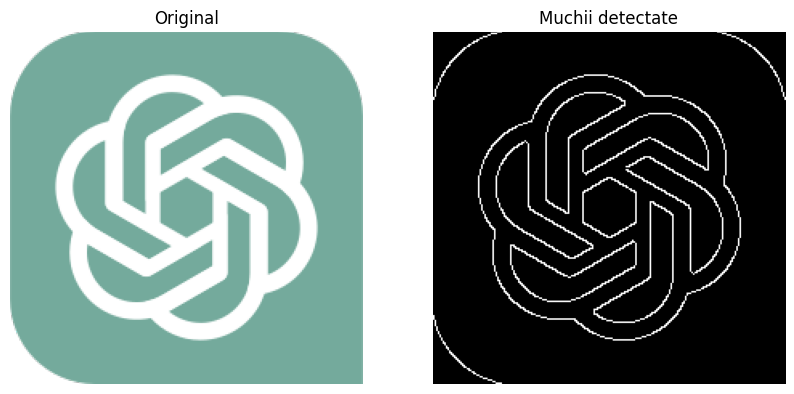

In [41]:
import requests
import random
from PIL import Image
from io import BytesIO
import numpy as np
import cv2
import matplotlib.pyplot as plt

gray_pil = normal_image.convert("L")  # transforma imaginea in grey scale deoarece algoritmul Canny functioneaza doar pe imagini alb-negru
gray = np.array(gray_pil)  # OpenCV lucreaza cu NumPy arrays, nu cu obiecte PIL, deci transformam imaginea intr-o matrice, unde fiecare numar reprezinta luminozitatea pixelului

edges = cv2.Canny(gray, threshold1=50, threshold2=150) # algoritmul lui Canny gaseste locurile unde exista schimbari puternice de intensitate

plt.figure(figsize=(10, 5))

# Imaginea originală
plt.subplot(1, 2, 1)
plt.imshow(normal_image)
plt.title("Original")
plt.axis("off")

# Imaginea cu muchii detectate
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Muchii detectate")
plt.axis("off")

plt.show()

Problema 3: Se da un fisier care contine un text (format din mai multe propozitii) in limba romana - a se vedea fisierul ”data/texts.txt”. Se cere sa se determine si sa se vizualizeze:

In [20]:
!wget -O texts.txt https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/texts.txt

with open("texts.txt", "r", encoding="utf-8") as file:
  text = file.read()

--2026-03-08 16:19:58--  https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/texts.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1147 (1.1K) [text/plain]
Saving to: ‘texts.txt’

texts.txt           100%[===================>]   1.12K  --.-KB/s    in 0s      

2026-03-08 16:19:58 (59.4 MB/s) - ‘texts.txt’ saved [1147/1147]



In [56]:
# Numarul de propozitii din text
import re
sentences = re.split(r'(?<=[.!?])\s+', text.strip())
# ?<= - verifica daca exista in fata unul dintre semnele ., !, ?
# [.!?] - oricare dintre aceste caractere
# \s+ - unul sau mai multe spatii

num_sentences = len(sentences)

print(f"Numarul de propozitii din text: {num_sentences}")

Numarul de propozitii din text: 10


In [50]:
# Numarul de cuvinte din text
words = re.findall(r'\b\w+\b', text)  # \b - un separator de cuvinte de exemplu spatii
                                      # \w+ - oricate caractere alfanumerice, w inseamna caracter numeric, iar "+" inseamna oricate
num_words = len(words)

print(f"Numarul de cuvinte din text: {num_words}")

Numarul de cuvinte din text: 160


In [51]:
# Numarul de cuvinte diferite din text
different_words = set(words)
num_different_words = len(different_words)

print(f"Numarul de cuvinte diferite din text: {num_different_words}")

Numarul de cuvinte diferite din text: 97


In [52]:
# Cel mai scurt si cel mai lung cuvant (cuvinte)
shortest_word = min(different_words, key=len)
longest_word = max(different_words, key=len)

print(f"Cel mai scurt cuvant: {shortest_word}")
print(f"Cel mai lung cuvant: {longest_word}")

Cel mai scurt cuvant: e
Cel mai lung cuvant: Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm


In [55]:
# Textul fara diacritice
diacritics_with_replacement_map = {
        'ă': 'a', 'â': 'a', 'î': 'i', 'ș': 's', 'ş': 's', 'ț': 't', 'ţ': 't',
        'Ă': 'A', 'Â': 'A', 'Î': 'I', 'Ș': 'S', 'Ş': 'S', 'Ț': 'T', 'Ţ': 'T'
    }
with open("texts.txt", "r", encoding="utf-8") as file:
  text_no_diacritics = file.read()

for diacritic, replacement in diacritics_with_replacement_map.items():
  text_no_diacritics = text_no_diacritics.replace(diacritic, replacement)

print(text_no_diacritics)


Mesaj de informare: 
Cursul si laboratoarele de Inteligenta Artificiala vor fi o 
provocare pentru toti. Suntem convinsi ca veti realiza proiecte 
foarte interesante. Va incurajam sa adresati intrebari atunci 
cand ceva nu e clar, atat in mod live, cat si folosind platforma 
Teams, canalul ”general”. 
Daca ati citit pana aici, va rugam sa lasati un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm ca am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimati cursanti,
Suntem incantati sa va avem in echipa noastra pentru Cursul si 
laboratoarele de Inteligenta Artificiala. Aceasta experienta va 
fi o adevarata provocare, dar suntem convinsi ca veti realiza 
proiecte extrem de interesante.
Va incurajam sa fiti activi si sa adresati intrebari atunci cand 
ceva nu este clar. Fie ca este vorba de o discutie in timp real 
sau prin intermediul platformei Teams, canalul ”general”, suntem 
aici sa va sprijinim.
Succes si sa inceapa ave

In [57]:
import nltk
from nltk.corpus import wordnet

# Descărcăm WordNet dacă nu este deja descărcat
nltk.download('wordnet')
nltk.download('omw')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw to /root/nltk_data...


True

In [61]:
# Sinonimele celui mai lung cuvant din text
longest_word_normalized = re.sub(r'(.)\1+', r'\1', longest_word)

synonyms = set() # sinonimele din WordNet pot aparea de mai multe ori, de aceea folosim set
for syn in wordnet.synsets(longest_word_normalized): # parcurge toate sensurile cuvantului din WordNet
  for lemma in syn.lemmas(): # pentru fiecare sens, parcurge toate sinonimele..acestea se pot repeta de aceea am folosit un set
    synonyms.add(lemma.name())

print(f"Sinonime pentru cuvantul {longest_word_normalized} sunt {synonyms}")


Sinonime pentru cuvantul Confirm sunt {'corroborate', 'reassert', 'sustain', 'affirm', 'substantiate', 'support', 'confirm'}


In [8]:
# Problema 4 - Normalizare
# problema 1 - durata anilor de studii universitare, vechimea in programare
import pandas as pd

def normalize_decimal_scaling(_data, column, mapping):
    _data[column + "_Numeric"] = _data[column].map(mapping)
    _data = _data.dropna().reset_index(drop=True)

    max_val = _data[column + "_Numeric"].abs().max()
    j = len(str(int(max_val))) if max_val > 0 else 1
    # Determinam puterea lui 10 pentru cea mai mare valoare, ca ulterior toate
    # valorile sa fie in intervalul [0, 1]
    _data[column + "_Normalized"] = _data[column + "_Numeric"] / (10**j)

    return _data


mapping_years = {
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25
}

!wget -O surveyDataSience.csv https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/surveyDataSience.csv
_data = pd.read_csv("surveyDataSience.csv")
df_selected = _data.iloc[1:, :][["Q4", "Q6"]].copy()

normalized_data = normalize_decimal_scaling(df_selected, "Q6", mapping_years)

mapping_education = {
    "No formal education past high school": 0,
    "Some college/university study without earning a bachelor’s degree": 2,
    "Professional degree": 5,
    "Bachelor’s degree": 3,
    "Master’s degree": 5,
    "Doctoral degree": 8
}

normalized_data = normalize_decimal_scaling(normalized_data, "Q4", mapping_education)

print(normalized_data.head())


--2026-03-08 15:53:02--  https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/surveyDataSience.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35220982 (34M) [text/plain]
Saving to: ‘surveyDataSience.csv’

surveyDataSience.cs 100%[===================>]  33.59M  --.-KB/s    in 0.08s   

2026-03-08 15:53:02 (433 MB/s) - ‘surveyDataSience.csv’ saved [35220982/35220982]

                  Q4          Q6  Q6_Numeric  Q6_Normalized  Q4_Numeric  \
0  Bachelor’s degree  5-10 years         7.5          0.075         3.0   
1    Master’s degree   20+ years        25.0          0.250         5.0   
2    Master’s degree   1-3 years         2.0          0.020         5.0   
3    Doctoral degree   20+ years        25.0        

/tmp/ipykernel_903/1977198299.py:28: DtypeWarning: Columns (0,18,32,49,56,69,88,100,107,113,139,184,195,201,202,253,266,278,283,285,286,287,288,289,290,291,292,301,322,339,347,355,367) have mixed types. Specify dtype option on import or set low_memory=False.
  _data = pd.read_csv("surveyDataSience.csv")


Min-max scaling


Text(0.5, 1.0, 'Histograma după min-max scaling')

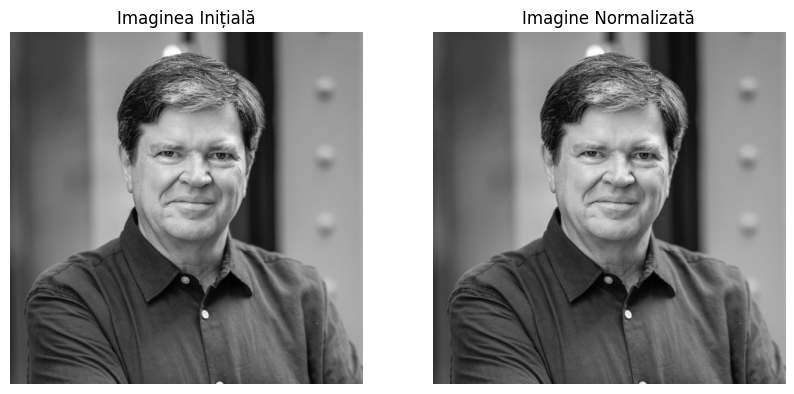

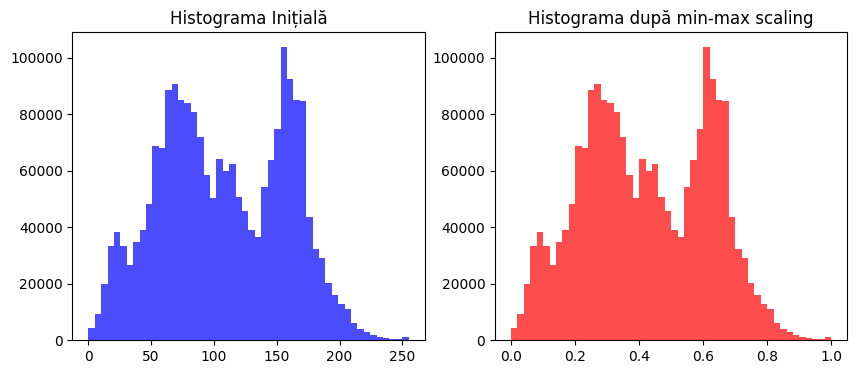

In [19]:
# problema 2: valorile pixelilor din imagini
import numpy as np

print("Min-max scaling")

image = image.convert("L") # se converteste imaginea in grayscale

image_np = np.array(image, dtype=np.float32) # transformam imaginea intr-o matrice de pixeli

# Se calculeaza cel mai luminos si cel mai intunecat pixel
min_pixel = np.min(image_np)
max_pixel = np.max(image_np)

# Se aplica formula de la normalizarea min-max : (x - min) / (max - min)
image_min_max = (image_np - min_pixel) / (max_pixel - min_pixel)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image_np, cmap="gray")
ax[0].set_title(f"Imaginea Inițială")
ax[0].axis("off")

ax[1].imshow(image_min_max, cmap="gray")
ax[1].set_title(f"Imagine Normalizată")
ax[1].axis("off")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(image_np.flatten(), bins=50, color='blue', alpha=0.7)
ax[0].set_title("Histograma Inițială")

ax[1].hist(image_min_max.flatten(), bins=50, color='red', alpha=0.7)
ax[1].set_title("Histograma după min-max scaling")


In [27]:
# problema 3 - numarul de aparitii a cuvintelor la nivelul unei propozitii

import numpy as np
from sklearn.preprocessing import MinMaxScaler
import re

sentences = re.split(r'[.!?]', text)
sentences = [s.strip().lower() for s in sentences if s.strip()]

# Calculam frecventa pentru fiecare cuvant
word_counts = []
for sentence in sentences:
  words = re.findall(r'\b\w+\b', sentence)  # Extrage doar cuvintele
  freq = {word: words.count(word) for word in set(words)}
  word_counts.append(freq)

# Se creeaza o lista unica cu toate cuvintele unice din text
unique_words = sorted(set(word for freq in word_counts for word in freq))

# Se creeaza Bag-of-Words matrix - adica o matrice unde se ia fiecare propozitie pe rand(propozitiile reprezinta linii in matrice) si pentru fiecare cuvant din lista
# de cuvinte unice se pune in matrice 0 sau 1 in functie de aparitia cuvantului
word_matrix = np.array([[freq.get(word, 0) for word in unique_words] for freq in word_counts])

min_max_scaler = MinMaxScaler() # algoritmul care foloseste formula de la normalizarea min-max
normalized_matrix = min_max_scaler.fit_transform(word_matrix)

for i, sentence in enumerate(sentences):
    print(f"Propoziția {i+1}: {sentence}")
    print(f" Normalizat: {normalized_matrix[i]}")


Propoziția 1: mesaj de informare: 
cursul și laboratoarele de inteligență artificială vor fi o 
provocare pentru toți
 Normalizat: [0.         0.         0.         0.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 1.         0.         0.         0.         0.         0.
 0.66666667 0.         0.         0.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.         1.         1.         0.
 0.         0.         1.         0.         0.         1.
 0.         0.         0.         1.         0.         1.
 0.         0.         0.         0.         0.         1.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         1.         0.         0.         0.         1.
 0.         0.         0.         0.       